In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── โหลดไฟล์ ─────────────────────────────────────────────────────────────────
products = pd.read_csv("sephora_products_clean.csv", encoding="utf-8-sig")
reviews  = pd.read_csv("sephora_reviews_clean.csv",  encoding="utf-8-sig")

# ── Merge reviews + products (เอาเฉพาะ column ที่ reviews ไม่มี) ──────────────
prod_cols = ["product_id", "secondary_category", "highlights", "loves_count"]
df = reviews.merge(products[prod_cols], on="product_id", how="left")

print(f"Shape: {df.shape}")
print(df["skin_type"].value_counts())

Shape: (32999, 17)
skin_type
combination    16124
dry             5694
normal          4037
oily            3719
unknown         3425
Name: count, dtype: int64


In [7]:
# ── แยกกลุ่ม Medical Claim จาก highlights ────────────────────────────────────
medical_keywords = [
    "dermatologist tested", "dermatologist recommended",
    "dermatologist approved", "clinically tested",
    "clinically proven", "medical grade", "doctor tested",
    "allergy tested", "hypoallergenic", "non-comedogenic"
]

def has_medical_claim(text):
    if pd.isna(text):
        return False
    return any(kw in str(text).lower() for kw in medical_keywords)

products["is_medical"] = products["highlights"].apply(has_medical_claim)

df = df.merge(products[["product_id", "is_medical"]], on="product_id", how="left")
df["is_medical"]  = df["is_medical"].fillna(False)
df["claim_group"] = df["is_medical"].map({True: "Medical Claim", False: "General"})

print(df["claim_group"].value_counts())
print(f"\nสัดส่วน Medical Claim: {df['is_medical'].mean()*100:.1f}%")

claim_group
General          32590
Medical Claim      409
Name: count, dtype: int64

สัดส่วน Medical Claim: 1.2%


In [10]:
df.head()

,author_id,rating,is_recommended,helpfulness,total_feedback_count,submission_time,review_text,review_title,skin_tone,skin_type,product_id,product_name,brand_name,price_usd,secondary_category,highlights,loves_count,is_medical,claim_group
0,11636537912,1,0.0,0.833333,12,22/07/2020,"This product burnt my skin, absolutely not wor...",NaN,fairLight,combination,P429952,Jet Lag Mask,Summer Fridays,49.0,Masks,"['Vegan', 'Hyaluronic Acid', 'Hydrating', 'Cle...",245435,False,General
1,1314143432,1,0.0,0.904762,21,08/08/2019,"Tried this because I LOVE their glycolic mask,...","Wanted to love this, broke me out.",deep,combination,P428095,Ready Steady Glow Daily AHA Tonic,REN Clean Skincare,40.0,Cleansers,"['Vegan', 'Recyclable Packaging', 'Good for: D...",76269,False,General
2,24208248841,2,0.0,0.750000,4,31/10/2022,"I have mature, sensitive dry skin and this lef...",Did not work for me.,tan,dry,P456126,Vegan Milk Cleanser,MILK MAKEUP,30.0,Cleansers,"['Clean at Sephora', 'Good for: Dryness', 'Veg...",17898,False,General
3,6185592049,1,0.0,0.269231,78,30/05/2019,RUN! Within the first 24hours I noticed the wr...,Nope Nope Nope,lightMedium,combination,P442753,Argireline Solution 10%,The Ordinary,9.4,Treatments,"['Vegan', 'Good for: Anti-Aging', 'Fragrance F...",85389,False,General
4,23073263341,1,0.0,1.000000,2,23/05/2021,This Product was really disappointing. The sme...,Just no..,lightMedium,combination,P469482,Even Skin Tone Self-Tanning Body Butter,Isle of Paradise,28.0,Self Tanners,"['Vegan', 'Good for: Dullness/Uneven Texture',...",34228,False,General


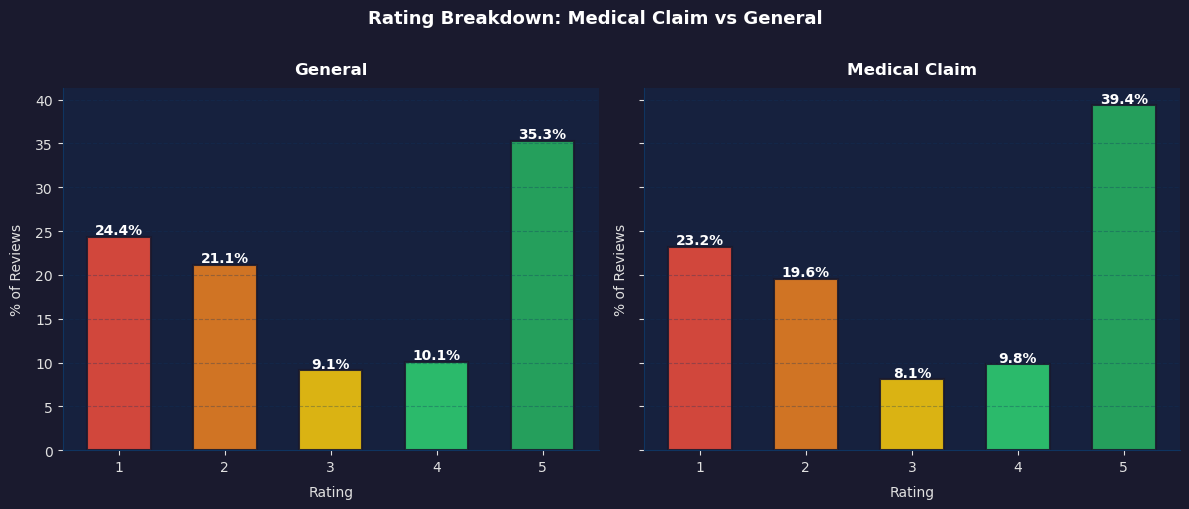

In [45]:
# ── กราฟ 1: Rating Breakdown ──────────────────────────────────────────────────
rating_pct = (df.groupby(["claim_group", "rating"])
              .size().reset_index(name="count"))
rating_pct["pct"] = (rating_pct.groupby("claim_group")["count"]
                     .transform(lambda x: x / x.sum() * 100))

rating_colors = {1: "#E74C3C", 2: "#E67E22", 3: "#F1C40F",
                 4: "#2ECC71", 5: "#27AE60"}

with plt.rc_context({
    "figure.facecolor": "#1A1A2E", "axes.facecolor": "#16213E",
    "axes.edgecolor":   "#0F3460", "axes.labelcolor": "#E0E0E0",
    "xtick.color":      "#E0E0E0", "ytick.color":     "#E0E0E0",
    "text.color":       "#FFFFFF", "grid.color":      "#0F3460",
    "grid.linestyle":   "--",      "font.size":       10,
    "axes.spines.top":  False,     "axes.spines.right": False,
}):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    for ax, grp in zip(axes, ["General", "Medical Claim"]):
        sub = rating_pct[rating_pct["claim_group"] == grp].sort_values("rating")
        bars = ax.bar(sub["rating"], sub["pct"],
                      color=[rating_colors[r] for r in sub["rating"]],
                      width=0.6, alpha=0.9, edgecolor="#1A1A2E", linewidth=1.5)
        for bar, v in zip(bars, sub["pct"]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold",
                    color="white")
        ax.set_title(grp, fontsize=12, fontweight="bold", color="white", pad=10)
        ax.set_xlabel("Rating", labelpad=8)
        ax.set_ylabel("% of Reviews", labelpad=8)
        ax.set_xticks([1, 2, 3, 4, 5])
        ax.grid(axis="y", alpha=0.3)

    plt.suptitle("Rating Breakdown: Medical Claim vs General",
                 fontsize=13, fontweight="bold", y=1.01, color="white")
    plt.tight_layout()
    plt.savefig("med_plot1_rating_breakdown.png", dpi=150, bbox_inches="tight",
                facecolor="#1A1A2E")
    plt.show()

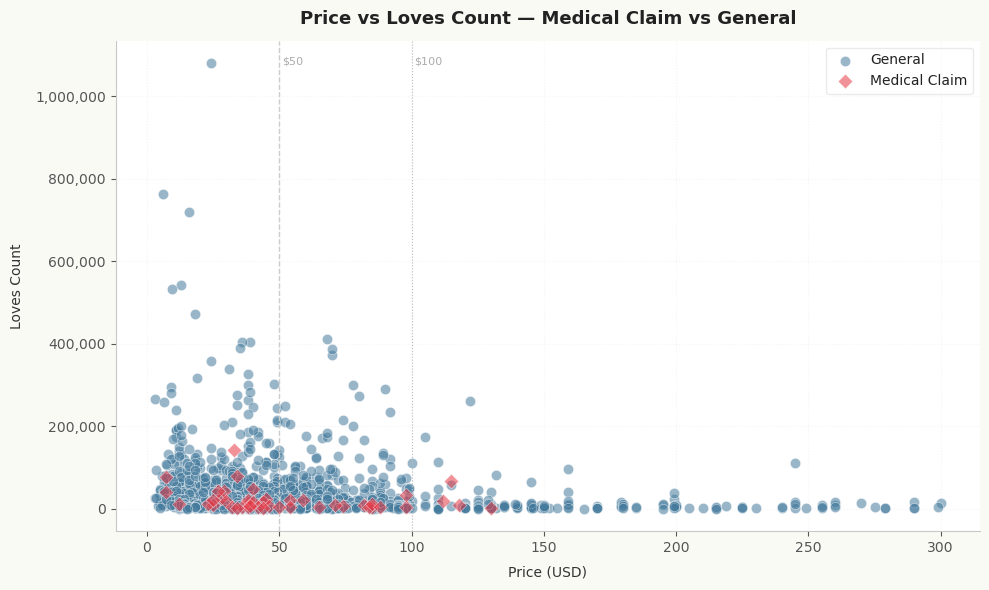

In [46]:
# ── กราฟ 2: Scatter Plot — Price vs Loves Count ───────────────────────────────
scatter_df = (df.groupby(["product_id", "claim_group"])
              .agg(
                  price_usd    = ("price_usd",    "mean"),
                  loves_count  = ("loves_count",  "mean"),
              )
              .reset_index()
              .query("price_usd > 0 and loves_count > 0 and price_usd <= 300"))

with plt.rc_context({
    "figure.facecolor": "#FAFAF5", "axes.facecolor": "#FFFFFF",
    "axes.edgecolor":   "#C8C8C8", "axes.labelcolor": "#333333",
    "xtick.color":      "#555555", "ytick.color":     "#555555",
    "text.color":       "#222222", "grid.color":      "#EBEBEB",
    "grid.linestyle":   ":",       "font.size":       10,
    "axes.spines.top":  False,     "axes.spines.right": False,
}):
    MED2 = "#E63946"   # แดง = Medical Claim
    GEN2 = "#457B9D"   # น้ำเงินเทา = General

    fig, ax = plt.subplots(figsize=(10, 6))
    for grp, color, marker, zorder in [
        ("General",       GEN2, "o", 2),
        ("Medical Claim", MED2, "D", 3)
    ]:
        sub = scatter_df[scatter_df["claim_group"] == grp]
        ax.scatter(sub["price_usd"], sub["loves_count"],
                   c=color, marker=marker, alpha=0.55,
                   s=55, label=grp, zorder=zorder,
                   edgecolors="white", linewidths=0.5)

    ax.axvline(50,  color="#CCCCCC", linewidth=1,   linestyle="--")
    ax.axvline(100, color="#BBBBBB", linewidth=0.8, linestyle=":")
    ax.text(51,  ax.get_ylim()[1] * 0.95, "$50",  fontsize=8, color="#AAAAAA")
    ax.text(101, ax.get_ylim()[1] * 0.95, "$100", fontsize=8, color="#AAAAAA")

    ax.set_title("Price vs Loves Count — Medical Claim vs General",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Price (USD)", labelpad=8)
    ax.set_ylabel("Loves Count", labelpad=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
    ax.legend(framealpha=0.4)
    ax.grid(True, alpha=0.5)

    plt.tight_layout()
    plt.savefig("med_plot2_scatter_price_loves.png", dpi=150, bbox_inches="tight",
                facecolor="#FAFAF5")
    plt.show()

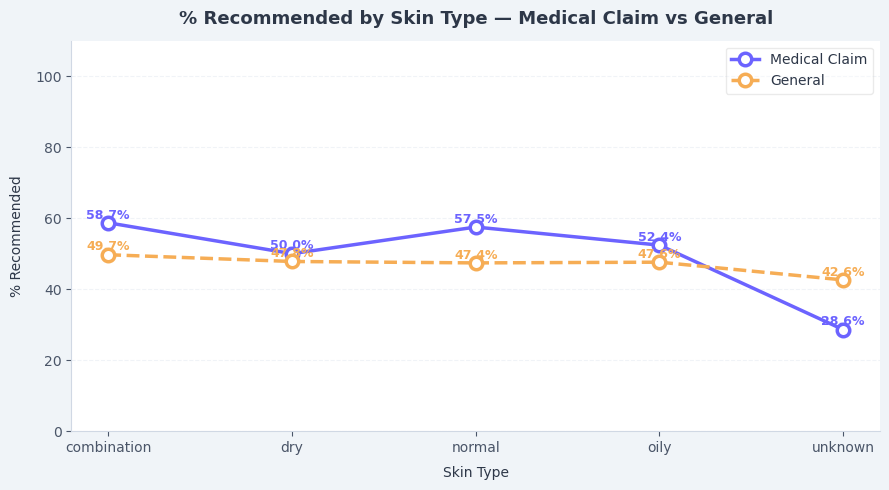

✅ บันทึกกราฟทั้ง 3 เรียบร้อย


In [47]:
# ── กราฟ 3: Line Chart — % Recommended by Skin Type ──────────────────────────
rec_by_skin = (df.groupby(["skin_type", "claim_group"])["is_recommended"]
               .mean().mul(100).round(1).reset_index(name="pct_recommended"))

with plt.rc_context({
    "figure.facecolor": "#F0F4F8", "axes.facecolor":  "#FFFFFF",
    "axes.edgecolor":   "#D0D8E4", "axes.labelcolor":  "#2D3748",
    "xtick.color":      "#4A5568", "ytick.color":      "#4A5568",
    "text.color":       "#2D3748", "grid.color":       "#E2E8F0",
    "grid.linestyle":   "--",      "font.size":        10,
    "axes.spines.top":  False,     "axes.spines.right": False,
}):
    MED3 = "#6C63FF"   # ม่วง = Medical Claim
    GEN3 = "#F6AD55"   # ส้ม  = General

    fig, ax = plt.subplots(figsize=(9, 5))
    for grp, color, ls in [("Medical Claim", MED3, "-"),
                             ("General",       GEN3, "--")]:
        sub = rec_by_skin[rec_by_skin["claim_group"] == grp].sort_values("skin_type")
        ax.plot(sub["skin_type"], sub["pct_recommended"],
                marker="o", label=grp, color=color,
                linewidth=2.5, markersize=9, linestyle=ls,
                markerfacecolor="white", markeredgewidth=2.5)
        for _, row in sub.iterrows():
            ax.text(row["skin_type"], row["pct_recommended"] + 1.2,
                    f"{row['pct_recommended']:.1f}%",
                    ha="center", fontsize=9, fontweight="bold", color=color)

    ax.set_title("% Recommended by Skin Type — Medical Claim vs General",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Skin Type", labelpad=8)
    ax.set_ylabel("% Recommended", labelpad=8)
    ax.set_ylim(0, 110)
    ax.legend(framealpha=0.4)
    ax.grid(axis="y", alpha=0.5)

    plt.tight_layout()
    plt.savefig("med_plot3_recommended_line.png", dpi=150, bbox_inches="tight",
                facecolor="#F0F4F8")
    plt.show()

print("✅ บันทึกกราฟทั้ง 3 เรียบร้อย")

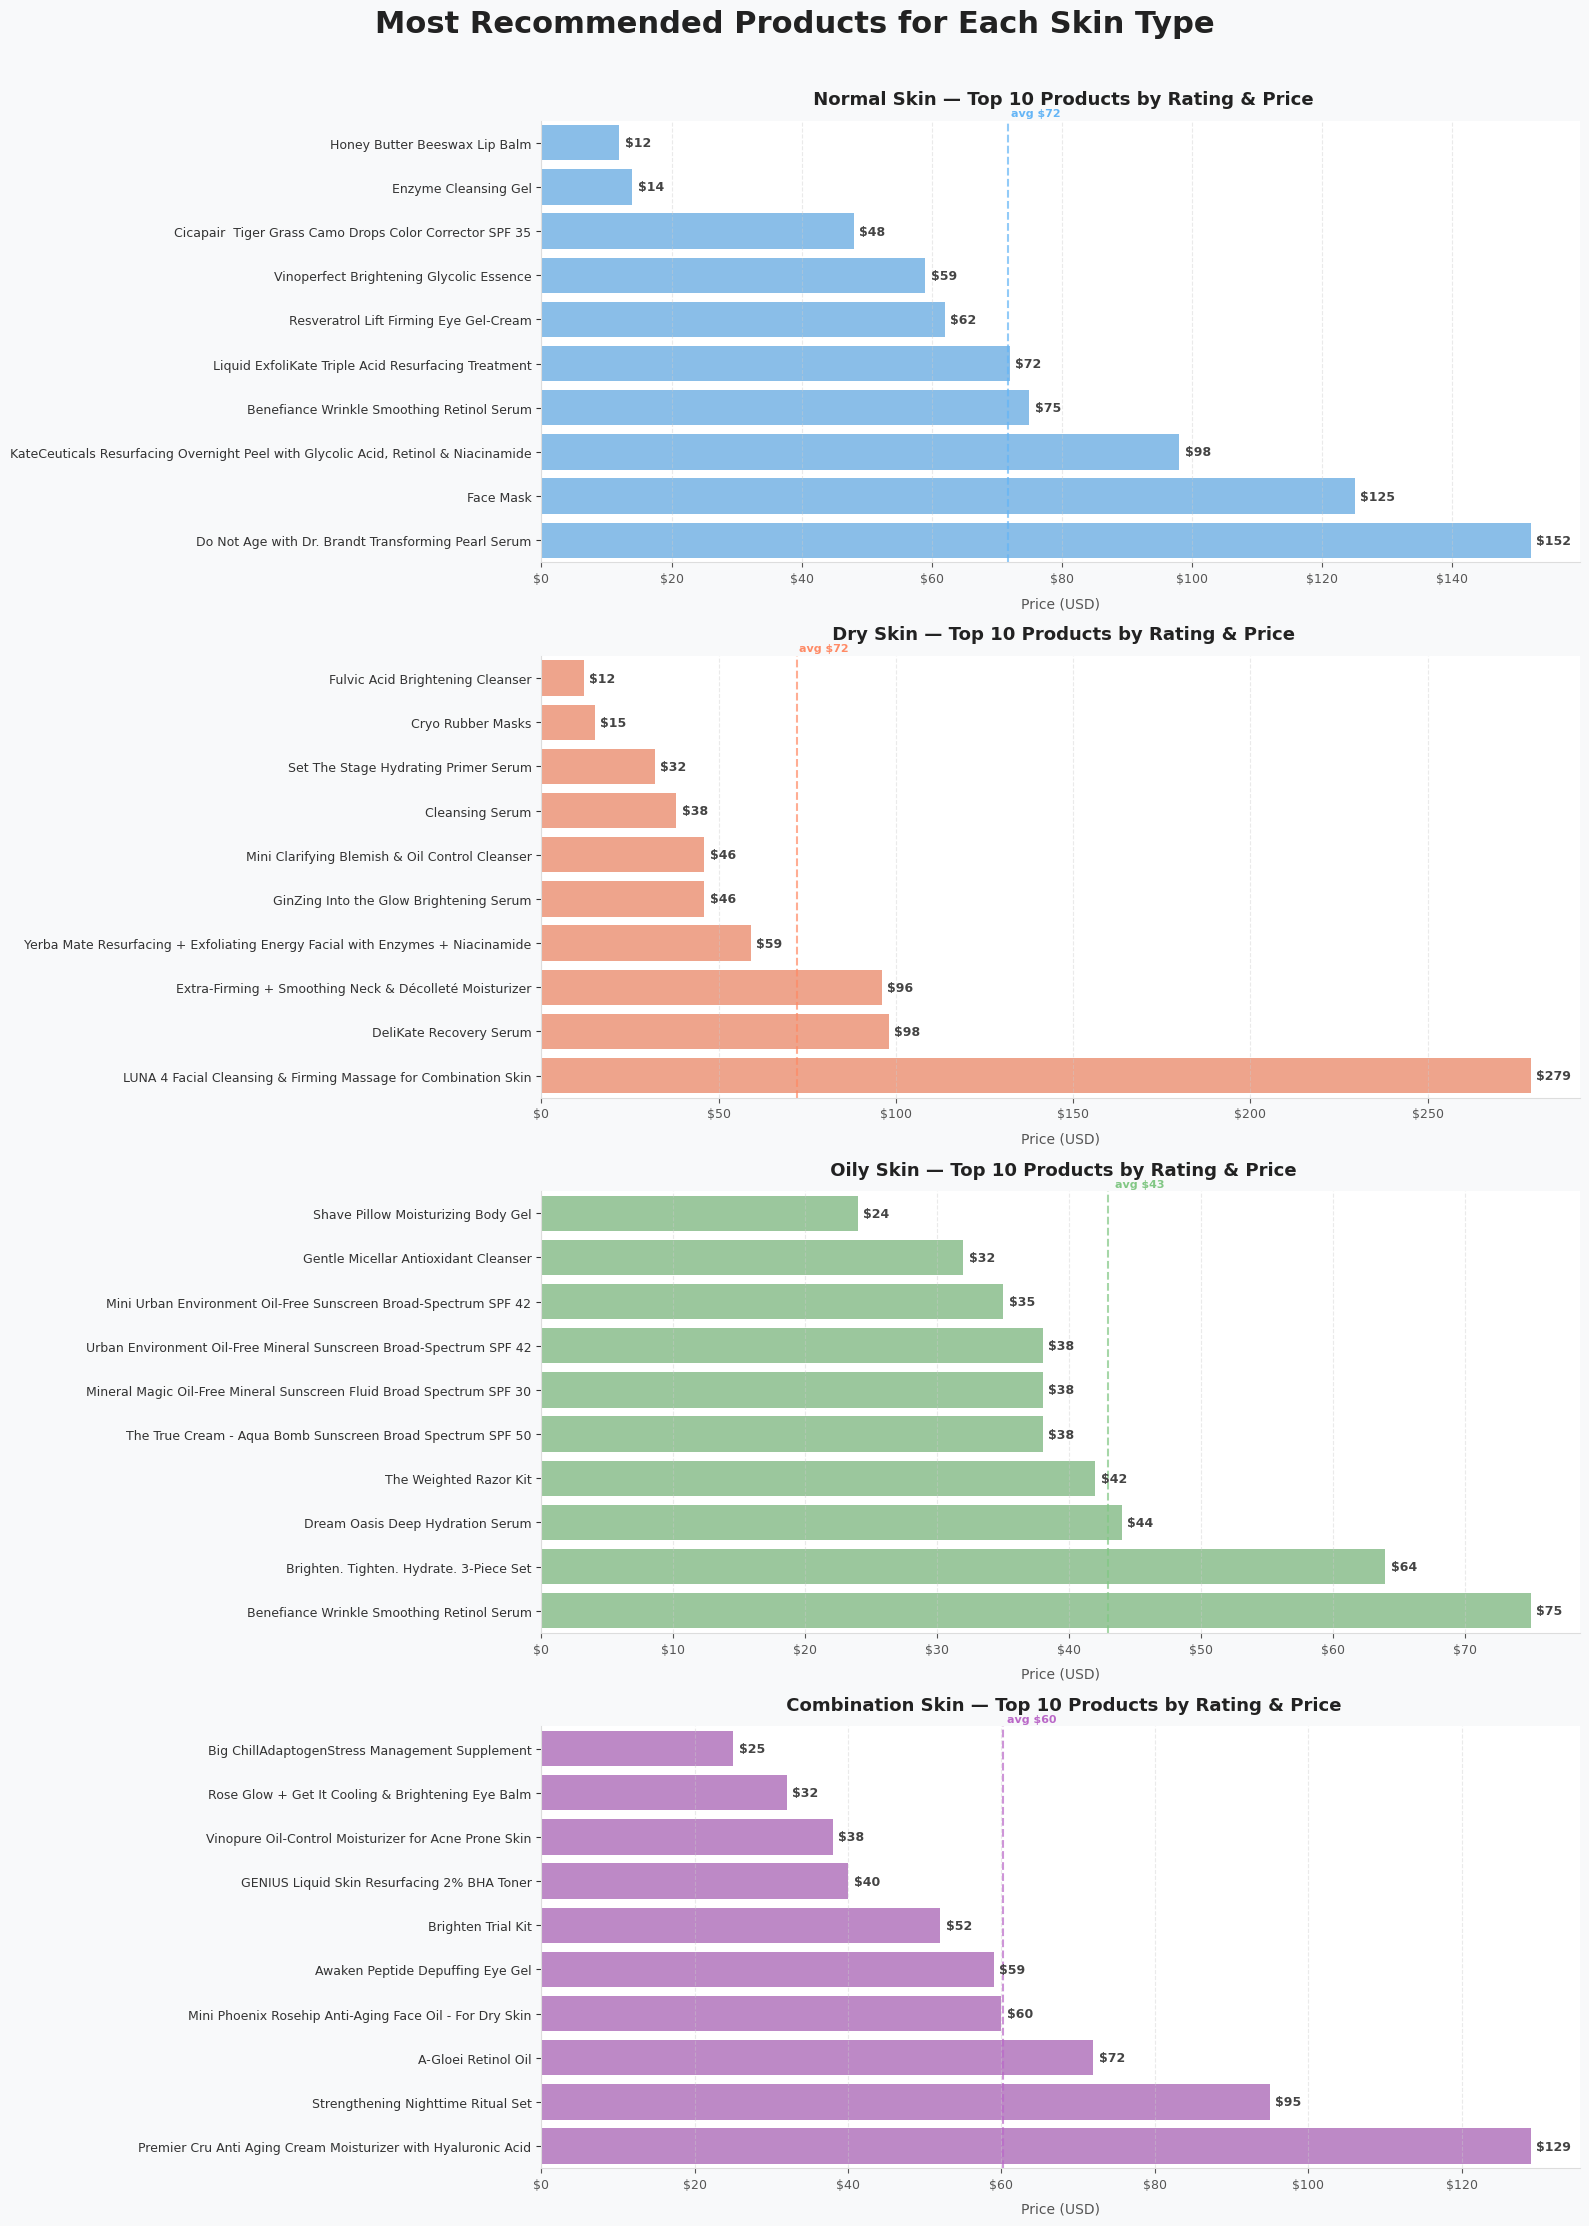

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── สี palette แต่ละ skin type ───────────────────────────────────────────────
SKIN_COLORS = {
    "normal":      "#64B5F6",   # ฟ้าอ่อน
    "dry":         "#FF8A65",   # ส้มอบอุ่น
    "oily":        "#81C784",   # เขียวสด
    "combination": "#BA68C8",   # ม่วง
}
BG      = "#F8F9FA"
CARD_BG = "#FFFFFF"

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(16, 22), facecolor=BG)
fig.subplots_adjust(hspace=0.6)

# ── เตรียมข้อมูล ──────────────────────────────────────────────────────────────
product_skin = (df.groupby(["skin_type", "product_id", "product_name", "price_usd"])
                .mean(numeric_only=True)["rating"].reset_index()
                .sort_values("rating", ascending=False))

skin_types = ["normal", "dry", "oily", "combination"]
titles = {
    "normal":      " Normal Skin — Top 10 Products by Rating & Price",
    "dry":         " Dry Skin — Top 10 Products by Rating & Price",
    "oily":        " Oily Skin — Top 10 Products by Rating & Price",
    "combination": " Combination Skin — Top 10 Products by Rating & Price",
}

for ax, skin in zip(axes, skin_types):
    # ── filter ข้อมูลแต่ละ skin type ─────────────────────────────────────────
    sub = (product_skin[product_skin["skin_type"] == skin]
           .sort_values("rating", ascending=False).head(10)
           .sort_values("price_usd", ascending=True))

    color = SKIN_COLORS[skin]

    # ── วาด barplot ───────────────────────────────────────────────────────────
    sns.barplot(data=sub, x="price_usd", y="product_name",
                color=color, alpha=0.85, ax=ax)

    # ── ใส่ตัวเลขท้าย bar ────────────────────────────────────────────────────
    for container in ax.containers:
        ax.bar_label(container, fmt="$%.0f",
                     padding=4, fontsize=9,
                     color="#444444", fontweight="bold")

    # ── ตกแต่ง ────────────────────────────────────────────────────────────────
    ax.set_facecolor(CARD_BG)
    ax.set_title(titles[skin], fontsize=13, fontweight="bold",
                 pad=12, color="#222222")
    ax.set_xlabel("Price (USD)", fontsize=10, color="#555555", labelpad=8)
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=9, colors="#333333")
    ax.tick_params(axis="x", labelsize=9, colors="#555555")
    ax.xaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda x,_: f"${int(x)}"))
    ax.grid(axis="x", linestyle="--", alpha=0.4, color="#CCCCCC")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#DDDDDD")
    ax.spines["bottom"].set_color("#DDDDDD")

    # ── เส้น reference ราคาเฉลี่ย ────────────────────────────────────────────
    avg_price = sub["price_usd"].mean()
    ax.axvline(avg_price, color=color, linewidth=1.5,
               linestyle="--", alpha=0.7)
    ax.text(avg_price + 0.5, -0.6, f"avg ${avg_price:.0f}",
            fontsize=8, color=color, fontweight="bold")

fig.suptitle("Most Recommended Products for Each Skin Type",
             fontsize=22, fontweight="bold", color="#222222", y=1.01)
fig.patch.set_facecolor(BG)

plt.tight_layout()
plt.savefig("top10_products_by_skin.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()